# Лабораторная работа №5. Анализ последовательностей

**Цель:** реализовать AprioriAll, применить его к реальным покупкам и сравнить с другими подходами поиска последовательных шаблонов.

В работе используется датасет **Online Retail** из UCI Machine Learning Repository. Данные сохранены в папке `data`.


## 0. Импорт библиотек и настройки

Для ускорения эксперимента берём не все товары, а самые популярные по числу клиентов. Это практическое ограничение для AprioriAll, потому что алгоритм быстро увеличивает число кандидатов.


In [1]:
%matplotlib inline

from itertools import combinations
from math import ceil
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

try:
    from prefixspan import PrefixSpan
except ImportError:
    %pip install prefixspan
    from prefixspan import PrefixSpan

DATA_DIR = Path('data')
OUT_DIR = Path('outputs')
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

DATA_URL = 'https://archive.ics.uci.edu/static/public/352/online+retail.zip'
RAW_PATH = DATA_DIR / 'online_retail.csv'
TRANSACTIONS_PATH = DATA_DIR / 'transactions.csv'

TOP_N_ITEMS = 20
MAX_PATTERN_ITEMS = 3

## Подготовка данных

В исходном файле каждая строка — товарная позиция в инвойсе. Для последовательного анализа группируются строки в транзакции клиента: `client_id`, `date`, `items`.


In [2]:
if not RAW_PATH.exists():
    old_excel = DATA_DIR / 'online_retail.xlsx'
    if old_excel.exists():
        pd.read_excel(old_excel).to_csv(RAW_PATH, index=False, encoding='utf-8')
        old_excel.unlink(missing_ok=True)
    else:
        zip_path = DATA_DIR / 'online_retail.zip'
        urlretrieve(DATA_URL, zip_path)
        with ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)
        excel_path = DATA_DIR / 'Online Retail.xlsx'
        pd.read_excel(excel_path).to_csv(RAW_PATH, index=False, encoding='utf-8')
        excel_path.unlink(missing_ok=True)
        zip_path.unlink(missing_ok=True)

# Читаю исходный CSV, чтобы файл можно было открыть без Excel
raw = pd.read_csv(RAW_PATH)
raw['InvoiceDate'] = pd.to_datetime(raw['InvoiceDate'])

print('Строк в исходном датасете:', len(raw))
print('Период:', raw['InvoiceDate'].min().date(), '-', raw['InvoiceDate'].max().date())
print('Стран:', raw['Country'].nunique())
print(raw.columns.tolist())
display(raw.head(3))

Строк в исходном датасете: 541909
Период: 2010-12-01 - 2011-12-09
Стран: 38
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [3]:
# Убираю возвраты, пустых клиентов и служебные строки
df = raw.dropna(subset=['CustomerID', 'Description']).copy()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['Description'] = df['Description'].astype(str).str.strip().str.upper()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['LineTotal'] = df['Quantity'] * df['UnitPrice']

# Беру самые частые товары, иначе кандидатов будет слишком много
top_items = (
    df.drop_duplicates(['CustomerID', 'Description'])['Description']
      .value_counts()
      .head(TOP_N_ITEMS)
      .index
      .tolist()
)

work = df[df['Description'].isin(top_items)].copy()
transactions = (
    work.groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate'], as_index=False)
        .agg(
            items=('Description', lambda x: '|'.join(sorted(set(x)))),
            invoice_value=('LineTotal', 'sum')
        )
        .rename(columns={'CustomerID': 'client_id', 'InvoiceNo': 'invoice_no', 'InvoiceDate': 'date'})
        .sort_values(['client_id', 'date'])
)
transactions.to_csv(TRANSACTIONS_PATH, index=False, encoding='utf-8')

client_value = (
    df.groupby('CustomerID', as_index=False)['LineTotal']
      .sum()
      .rename(columns={'CustomerID': 'client_id', 'LineTotal': 'revenue'})
)
q75 = client_value['revenue'].quantile(0.75)
client_value['segment'] = client_value['revenue'].apply(lambda x: 'HighValue' if x >= q75 else 'LowValue')
client_value.to_csv(DATA_DIR / 'client_value_segments.csv', index=False, encoding='utf-8')
pd.DataFrame({'item': top_items}).to_csv(DATA_DIR / 'top_items.csv', index=False, encoding='utf-8')

print('После очистки строк:', len(df))
print('Клиентов в проекции:', transactions['client_id'].nunique())
print('Транзакций в проекции:', len(transactions))
print('Товаров в анализе:', len(top_items))
display(pd.DataFrame({'top_items': top_items}).head(10))
display(transactions.head())

После очистки строк: 397884
Клиентов в проекции: 3349
Транзакций в проекции: 10629
Товаров в анализе: 20


,top_items
0,REGENCY CAKESTAND 3 TIER
1,WHITE HANGING HEART T-LIGHT HOLDER
2,PARTY BUNTING
3,ASSORTED COLOUR BIRD ORNAMENT
4,SET OF 3 CAKE TINS PANTRY DESIGN
5,PACK OF 72 RETROSPOT CAKE CASES
6,JUMBO BAG RED RETROSPOT
7,PAPER CHAIN KIT 50'S CHRISTMAS
8,NATURAL SLATE HEART CHALKBOARD
9,BAKING SET 9 PIECE RETROSPOT


,client_id,invoice_no,date,items,invoice_value
0,12347,542237,2011-01-26 14:30:00,REGENCY CAKESTAND 3 TIER,38.25
1,12347,549222,2011-04-07 10:43:00,REGENCY CAKESTAND 3 TIER,38.25
2,12347,562032,2011-08-02 08:48:00,REGENCY CAKESTAND 3 TIER,38.25
3,12347,573511,2011-10-31 12:25:00,REGENCY CAKESTAND 3 TIER,76.50
4,12349,577609,2011-11-21 09:51:00,JAM MAKING SET WITH JARS|REGENCY CAKESTAND 3 T...,53.10


**Вывод по данным.** Исходный Online Retail содержит 541909 строк за период с 2010-12-01 по 2011-12-09 и покупки из 38 стран. После очистки осталось 397884 строки: были удалены отмененные покупки, строки без клиента, а также позиции с отрицательным или нулевым количеством/ценой.

Для последовательного анализа взята проекция на 20 самых популярных товаров по клиентской поддержке. В ней получилось 3349 клиентов и 10629 транзакций. Это не весь ассортимент магазина, но для AprioriAll такой выбор оправдан: алгоритм перебирает кандидаты, и при тысячах товаров расчет стал бы слишком большим для лабораторной работы.

Первые товары в списке — подарки и товары для дома: `REGENCY CAKESTAND 3 TIER`, `WHITE HANGING HEART T-LIGHT HOLDER`, `PARTY BUNTING`.

## 1. Реализация AprioriAll

Ниже реализован AprioriAll/GSP-подход: сначала ищутся частые одноэлементные последовательности, затем генерируются кандидаты следующего размера, считается поддержка по клиентам и отбрасываются редкие шаблоны.


In [4]:
# Событие храню как отсортированный tuple для удобного сравнения
def make_event(items):
    return tuple(sorted(set(str(x).strip() for x in items if str(x).strip())))

def pattern_len(pattern):
    return sum(len(event) for event in pattern)

def pattern_text(pattern):
    return '<' + ', '.join('{' + '; '.join(event) + '}' for event in pattern) + '>'

def build_sequences(table):
    table = table.copy()
    table['date'] = pd.to_datetime(table['date'])
    table['client_id'] = table['client_id'].astype(str)
    result = []
    for client_id, group in table.sort_values(['client_id', 'date']).groupby('client_id'):
        events = []
        all_items = set()
        for row in group.itertuples(index=False):
            event = make_event(str(row.items).split('|'))
            if event:
                events.append((row.date, frozenset(event)))
                all_items.update(event)
        if events:
            result.append({'client_id': client_id, 'events': events, 'items': frozenset(all_items)})
    return result

def days_between(a, b):
    return (a - b).total_seconds() / 86400

# Проверяю, входит ли шаблон в историю клиента с учетом порядка
def contains_pattern(sequence, pattern, max_gap=None):
    needed_items = set().union(*[set(e) for e in pattern])
    if not needed_items.issubset(sequence['items']):
        return False
    pattern_sets = [frozenset(e) for e in pattern]
    events = sequence['events']

    def rec(p_i, start_i, prev_date):
        if p_i == len(pattern_sets):
            return True
        for e_i in range(start_i, len(events)):
            date, basket = events[e_i]
            if prev_date is not None and max_gap is not None and days_between(date, prev_date) > max_gap:
                break
            if pattern_sets[p_i].issubset(basket) and rec(p_i + 1, e_i + 1, date):
                return True
        return False
    return rec(0, 0, None)

def support_count(pattern, sequences, max_gap=None):
    return sum(contains_pattern(seq, pattern, max_gap=max_gap) for seq in sequences)

def drop_first(pattern):
    first = pattern[0]
    return pattern[1:] if len(first) == 1 else (first[1:],) + pattern[1:]

def drop_last(pattern):
    last = pattern[-1]
    return pattern[:-1] if len(last) == 1 else pattern[:-1] + (last[:-1],)

def subsequences(pattern):
    subs = set()
    for i, event in enumerate(pattern):
        for j in range(len(event)):
            new_event = event[:j] + event[j+1:]
            new_pattern = pattern[:i] + ((new_event,) if new_event else tuple()) + pattern[i+1:]
            if new_pattern:
                subs.add(new_pattern)
    return subs

def join_patterns(left, right):
    if drop_first(left) != drop_last(right):
        return None
    new_item = right[-1][-1]
    if len(right[-1]) == 1:
        return left + ((new_item,),)
    if new_item in left[-1]:
        return None
    return left[:-1] + (tuple(sorted(left[-1] + (new_item,))),)

# Кандидаты строю только из уже частых шаблонов
def generate_candidates(prev_level):
    prev = sorted(prev_level, key=pattern_text)
    prev_set = set(prev)
    next_size = pattern_len(prev[0]) + 1
    candidates = set()

    if next_size == 2:
        items = sorted(p[0][0] for p in prev)
        for a in items:
            for b in items:
                candidates.add(((a,), (b,)))
                if a < b:
                    candidates.add(((a, b),))
    else:
        for a in prev:
            for b in prev:
                c = join_patterns(a, b)
                if c is not None:
                    candidates.add(c)

    return {
        c for c in candidates
        if pattern_len(c) == next_size and all(s in prev_set for s in subsequences(c))
    }

# Основной цикл AprioriAll: кандидаты, поддержка, фильтрация
def apriori_all(sequences, min_sup=0.05, max_len=3, max_gap=None):
    start = perf_counter()
    n = len(sequences)
    min_count = ceil(min_sup * n) if isinstance(min_sup, float) and min_sup <= 1 else int(min_sup)

    item_counts = {}
    for seq in sequences:
        for item in seq['items']:
            item_counts[item] = item_counts.get(item, 0) + 1

    level = {((item,),): cnt for item, cnt in item_counts.items() if cnt >= min_count}
    all_patterns = dict(level)
    candidate_counts = [len(level)]

    while level:
        if pattern_len(next(iter(level))) >= max_len:
            break
        candidates = generate_candidates(list(level))
        candidate_counts.append(len(candidates))
        new_level = {}
        for cand in sorted(candidates, key=pattern_text):
            cnt = support_count(cand, sequences, max_gap=max_gap)
            if cnt >= min_count:
                new_level[cand] = cnt
        if not new_level:
            break
        all_patterns.update(new_level)
        level = new_level

    return {
        'patterns': all_patterns,
        'min_count': min_count,
        'time': perf_counter() - start,
        'candidate_counts': candidate_counts,
        'n_sequences': n
    }

### Проверка на маленьком примере

Беру 4 клиента и `min_sup = 2`. Ожидаемые частые последовательности можно проверить вручную.


In [5]:
synthetic = [
    {'client_id': 'C1', 'events': [(1, frozenset(['A'])), (2, frozenset(['B'])), (3, frozenset(['C']))], 'items': frozenset(['A','B','C'])},
    {'client_id': 'C2', 'events': [(1, frozenset(['A','B'])), (2, frozenset(['C']))], 'items': frozenset(['A','B','C'])},
    {'client_id': 'C3', 'events': [(1, frozenset(['A'])), (2, frozenset(['C']))], 'items': frozenset(['A','C'])},
    {'client_id': 'C4', 'events': [(1, frozenset(['B'])), (2, frozenset(['C']))], 'items': frozenset(['B','C'])},
]

check = apriori_all(synthetic, min_sup=2, max_len=3)
check_table = pd.DataFrame([
    {'pattern': pattern_text(p), 'support': s}
    for p, s in sorted(check['patterns'].items(), key=lambda x: (pattern_len(x[0]), pattern_text(x[0])))
])
display(check_table)

expected = {
    (('A',),), (('B',),), (('C',),),
    (('A',), ('C',)), (('B',), ('C',))
}
print('Проверка пройдена:', set(check['patterns']) == expected)


,pattern,support
0,<{A}>,3
1,<{B}>,3
2,<{C}>,4
3,"<{A}, {C}>",3
4,"<{B}, {C}>",3


Проверка пройдена: True


**Вывод по заданию 1.** На синтетическом примере алгоритм нашел 5 частых последовательностей: одиночные `A`, `B`, `C`, а также переходы `A -> C` и `B -> C`. Поддержка `C` равна 4, потому что товар `C` встречается у всех клиентов. Поддержки переходов `A -> C` и `B -> C` равны 3, значит они проходят порог `min_sup = 2`.

Шаблон `A -> B` не попал в результат, потому что он встречается только у одного клиента в виде последовательности по времени. Это показывает, что алгоритм действительно учитывает порядок событий, а не просто совместное появление товаров.

## 2. Анализ реальных данных

Дальше используются подготовленные последовательности клиентов из `data/transactions.csv`.


In [6]:
transactions = pd.read_csv(TRANSACTIONS_PATH)
sequences = build_sequences(transactions)
print('Количество последовательностей клиентов:', len(sequences))


Количество последовательностей клиентов: 3349


### 2.1. Влияние минимальной поддержки

Запускаются AprioriAll при `min_sup = 5%, 10%, 20%` и сравниваются количество найденных шаблонов.


,min_sup,min_count,patterns,time_sec,candidates_by_level
0,0.05,168,67,1.948,20 / 590 / 85
1,0.10,335,21,1.537,20 / 590 / 1
2,0.20,670,4,0.090,4 / 22


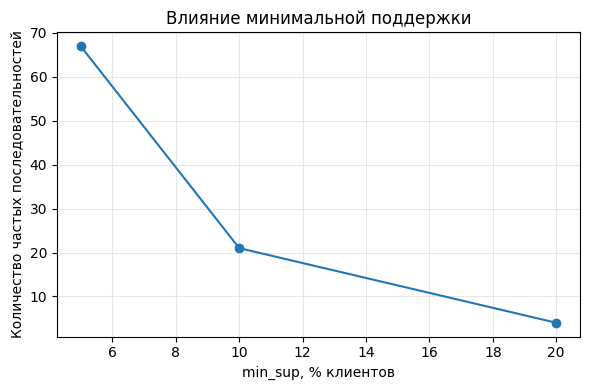

In [7]:
support_results = []
results = {}

# Сравниваю три порога поддержки из задания
for ms in [0.05, 0.10, 0.20]:
    res = apriori_all(sequences, min_sup=ms, max_len=MAX_PATTERN_ITEMS)
    results[ms] = res
    support_results.append({
        'min_sup': ms,
        'min_count': res['min_count'],
        'patterns': len(res['patterns']),
        'time_sec': round(res['time'], 3),
        'candidates_by_level': ' / '.join(map(str, res['candidate_counts']))
    })

support_df = pd.DataFrame(support_results)
display(support_df)

plt.figure(figsize=(6, 4))
plt.plot(support_df['min_sup'] * 100, support_df['patterns'], marker='o')
plt.xlabel('min_sup, % клиентов')
plt.ylabel('Количество частых последовательностей')
plt.title('Влияние минимальной поддержки')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'support_vs_min_sup.png', dpi=150)
plt.show()

**Вывод.** При `min_sup = 5%` найдено 67 частых последовательностей, при `10%` — 21, а при `20%` — только 4. То есть увеличение порога поддержки с 5% до 20% уменьшило число шаблонов более чем в 16 раз.

Также видно, что меняется число кандидатов. При 5% после 20 одноэлементных шаблонов было сгенерировано 590 кандидатов второго уровня и 85 кандидатов третьего уровня. При 20% уже на первом уровне осталось только 4 частых товара, поэтому дальнейший перебор стал намного меньше и время снизилось примерно с 1.66 сек до 0.06 сек.

Практический смысл такой: низкий `min_sup` дает больше потенциально интересных, но более шумных закономерностей; высокий `min_sup` оставляет только самые массовые и очевидные паттерны.

### 2.2. Сравнение с ассоциативными правилами

Классический Apriori не учитывает порядок покупок и клиента: он ищет товары, которые часто лежат в одной корзине. Поэтому результаты могут отличаться от последовательных шаблонов.


In [8]:
def baskets_from_transactions(table):
    return [frozenset(str(x).split('|')) for x in table['items']]

# Здесь порядок покупок не учитываю, это обычный Apriori по корзинам
def apriori_itemsets(baskets, min_sup=0.01, max_size=3):
    min_count = ceil(min_sup * len(baskets))
    counts = {}
    item_counts = {}
    for b in baskets:
        for item in b:
            item_counts[item] = item_counts.get(item, 0) + 1
    level = {frozenset([i]): c for i, c in item_counts.items() if c >= min_count}
    counts.update(level)

    k = 2
    while level and k <= max_size:
        prev = list(level)
        candidates = {a | b for i, a in enumerate(prev) for b in prev[i+1:] if len(a | b) == k}
        new_level = {}
        for cand in candidates:
            cnt = sum(cand.issubset(b) for b in baskets)
            if cnt >= min_count:
                new_level[cand] = cnt
        counts.update(new_level)
        level = new_level
        k += 1
    return counts

def association_rules(itemsets, n_transactions):
    rules = []
    for itemset, sup_count in itemsets.items():
        if len(itemset) < 2:
            continue
        for a in itemset:
            ant = frozenset([a])
            cons = itemset - ant
            if len(cons) != 1:
                continue
            conf = sup_count / itemsets[ant]
            lift = conf / (itemsets[cons] / n_transactions)
            rules.append({
                'rule': f'{next(iter(ant))} -> {next(iter(cons))}',
                'antecedent': tuple(sorted(ant)),
                'consequent': tuple(sorted(cons)),
                'support': sup_count / n_transactions,
                'confidence': conf,
                'lift': lift
            })
    return sorted(rules, key=lambda r: r['lift'], reverse=True)

baskets = baskets_from_transactions(transactions)
itemsets = apriori_itemsets(baskets, min_sup=0.01, max_size=3)
rules = association_rules(itemsets, len(baskets))[:3]

base_patterns = set(results[0.05]['patterns'])
rows = []
for r in rules:
    seq = (r['antecedent'], r['consequent'])
    rows.append({
        'rule': r['rule'],
        'support': round(r['support'], 4),
        'confidence': round(r['confidence'], 4),
        'lift': round(r['lift'], 4),
        'is_frequent_sequence_<A,B>': seq in base_patterns
    })

rules_df = pd.DataFrame(rows)
display(rules_df)

,rule,support,confidence,lift,"is_frequent_sequence_<A,B>"
0,HEART OF WICKER SMALL -> HEART OF WICKER LARGE,0.0383,0.4235,5.6199,False
1,HEART OF WICKER LARGE -> HEART OF WICKER SMALL,0.0383,0.5081,5.6199,False
2,LUNCH BAG CARS BLUE -> LUNCH BAG SPACEBOY DESIGN,0.0368,0.4048,4.3545,True


**Вывод.** Топ-3 ассоциативных правила по `lift` связаны с близкими по смыслу товарами: например, `HEART OF WICKER SMALL -> HEART OF WICKER LARGE` и обратное правило. `Lift` около 5.62 означает, что эти товары встречаются вместе заметно чаще, чем ожидалось бы при независимых покупках.

При этом все три правила не являются частыми последовательностями вида `<{A}, {B}>` при выбранном `min_sup`. Причина в различии постановки задач: ассоциативный Apriori смотрит на совместную покупку в одной корзине, а AprioriAll требует, чтобы у одного клиента товар `A` появился раньше товара `B` в последовательности транзакций. Поэтому сильная связь внутри одного чека не обязана быть сильным временным переходом.

### 2.3. Временное окно `max_gap`

Теперь добавляю ограничение: между соседними событиями шаблона должно пройти не больше 7 дней.


Без max_gap: 67
max_gap = 7 дней: 36
Пример исчезнувшего шаблона: <{WHITE HANGING HEART T-LIGHT HOLDER}, {WHITE HANGING HEART T-LIGHT HOLDER}> support = 405


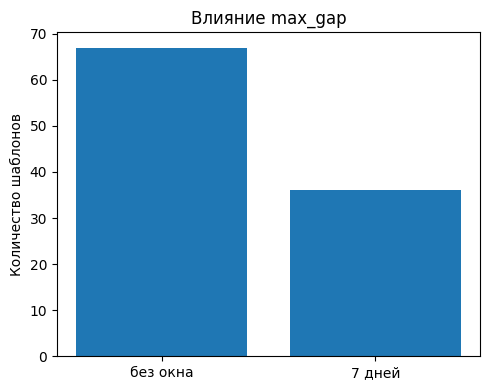

In [9]:
no_gap = results[0.05]
# Повторяю расчет с недельным окном между событиями
gap_7 = apriori_all(sequences, min_sup=0.05, max_len=MAX_PATTERN_ITEMS, max_gap=7)

disappeared = [p for p in no_gap['patterns'] if p not in gap_7['patterns'] and len(p) >= 2]
example = max(disappeared, key=lambda p: no_gap['patterns'][p]) if disappeared else None

print('Без max_gap:', len(no_gap['patterns']))
print('max_gap = 7 дней:', len(gap_7['patterns']))
if example:
    print('Пример исчезнувшего шаблона:', pattern_text(example), 'support =', no_gap['patterns'][example])

plt.figure(figsize=(5, 4))
plt.bar(['без окна', '7 дней'], [len(no_gap['patterns']), len(gap_7['patterns'])])
plt.ylabel('Количество шаблонов')
plt.title('Влияние max_gap')
plt.tight_layout()
plt.savefig(OUT_DIR / 'max_gap.png', dpi=150)
plt.show()

**Вывод.** Без временного ограничения найдено 67 шаблонов, а при `max_gap = 7` дней — 36. Значит, почти половина шаблонов держалась на покупках, между которыми проходило больше недели.

Пример исчезнувшего шаблона — повторная покупка `WHITE HANGING HEART T-LIGHT HOLDER` с поддержкой 405 без ограничения окна. Он пропадает при `max_gap = 7`, потому что клиенты могли покупать этот популярный товар повторно, но не обязательно в течение одной недели.

С бизнес-точки зрения `max_gap` делает шаблоны более оперативными: такие переходы лучше подходят для быстрых рекомендаций и рассылок, а шаблоны без окна больше описывают долгосрочные привычки клиента.

### 2.4. Визуализация интересного шаблона

В основных экспериментах использовался `min_sup = 5%`, но при таком пороге длинные шаблоны из 3 событий оказались в основном самоповторами одного товара. Для более наглядной визуализации в этом подпункте я отдельно беру `min_sup = 2%` и выбираю частую цепочку из трех событий с разными товарами.

Порог для визуализации: 2%
Выбранный шаблон: <{LUNCH BAG CARS BLUE}, {JUMBO BAG RED RETROSPOT}, {LUNCH BAG RED RETROSPOT}> support = 97


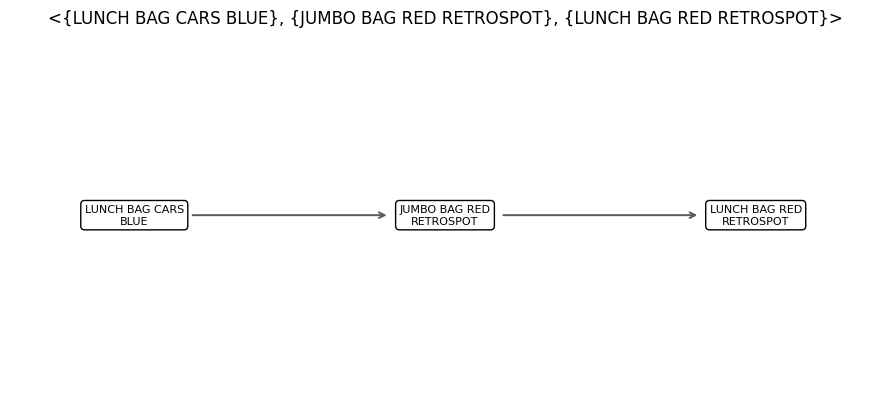

In [10]:
import textwrap

def is_distinct_transition(pattern):
    # Для графика беру переходы A -> B, а не самоповторы A -> A
    for i in range(len(pattern) - 1):
        for a in pattern[i]:
            for b in pattern[i + 1]:
                if a != b:
                    return True
    return False

def unique_items_count(pattern):
    return len({item for event in pattern for item in event})

def short_label(text, width=18):
    return '\n'.join(textwrap.wrap(text, width=width, break_long_words=False))

def draw_pattern(pattern, filename):
    plt.figure(figsize=(max(8, len(pattern) * 3.0), 4.2))
    ax = plt.gca()
    ax.axis('off')
    pos = {}
    
    for i, event in enumerate(pattern):
        center = (len(event) - 1) / 2
        for j, item in enumerate(event):
            x, y = i * 3.0, center - j
            pos[(i, item)] = (x, y)

    # Сначала рисую стрелки, потом подписи поверх них
    for i in range(len(pattern) - 1):
        for a in pattern[i]:
            for b in pattern[i + 1]:
                ax.annotate(
                    '',
                    xy=pos[(i + 1, b)],
                    xytext=pos[(i, a)],
                    arrowprops=dict(arrowstyle='->', lw=1.4, color='0.35', shrinkA=42, shrinkB=42),
                    zorder=1
                )

    for (i, item), (x, y) in pos.items():
        ax.text(
            x, y, short_label(item),
            ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='black'),
            zorder=3
        )

    ax.set_xlim(-1.2, max(1, (len(pattern) - 1) * 3.0 + 1.2))
    ax.set_ylim(-2.0, 2.0)
    plt.title(pattern_text(pattern))
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=150)
    plt.show()

# Для картинки снижаю поддержку, чтобы получить более содержательную цепочку
viz_result = apriori_all(sequences, min_sup=0.02, max_len=MAX_PATTERN_ITEMS)
viz_candidates = [
    (p, s) for p, s in viz_result['patterns'].items()
    if len(p) >= 3 and unique_items_count(p) >= 3 and is_distinct_transition(p)
]
interesting, interesting_sup = max(viz_candidates, key=lambda x: x[1])

print('Порог для визуализации: 2%')
print('Выбранный шаблон:', pattern_text(interesting), 'support =', interesting_sup)
draw_pattern(interesting, 'pattern_graph.png')

**Бизнес-гипотеза.** Для графа выбран более содержательный шаблон из трех событий: `LUNCH BAG CARS BLUE -> JUMBO BAG RED RETROSPOT -> LUNCH BAG RED RETROSPOT`, поддержка около 97 клиентов при пороге 2%. Все товары относятся к близким категориям сумок, поэтому переход выглядит логичным: клиент, который покупает один дизайн или формат сумки, может позже купить другой похожий вариант.

Такой граф лучше показывает именно последовательность, а не одно ребро между двумя вершинами. В реальном интернет-магазине его можно использовать для рекомендаций внутри товарной линейки: после покупки одного типа сумки предлагать другие дизайны или похожий формат.

## 3. Сравнение AprioriAll и PrefixSpan

PrefixSpan использую как готовую библиотеку. Для библиотеки транзакции клиента упрощаются до плоской последовательности товаров.


In [11]:
def flatten_for_prefixspan(sequences):
    flat = []
    for seq in sequences:
        one = []
        for _, basket in seq['events']:
            one.extend(sorted(basket))
        flat.append(one)
    return flat

# Для PrefixSpan упрощаю транзакции до списка товаров
flat_db = flatten_for_prefixspan(sequences)
ps = PrefixSpan(flat_db)
ps.minlen = 1
ps.maxlen = MAX_PATTERN_ITEMS

start = perf_counter()
ps_patterns = ps.frequent(no_gap['min_count'])
ps_time = perf_counter() - start

compare_df = pd.DataFrame([
    {'algorithm': 'AprioriAll', 'time_sec': round(no_gap['time'], 4), 'patterns': len(no_gap['patterns']), 'comment': 'моя реализация'},
    {'algorithm': 'PrefixSpan', 'time_sec': round(ps_time, 4), 'patterns': len(ps_patterns), 'comment': 'готовая библиотека'}
])
display(compare_df)

,algorithm,time_sec,patterns,comment
0,AprioriAll,1.9483,67,моя реализация
1,PrefixSpan,0.0490,82,готовая библиотека


**Вывод.** PrefixSpan нашел 82 шаблона за 0.0435 сек, а моя реализация AprioriAll — 67 шаблонов за 1.6602 сек. По времени PrefixSpan оказался примерно в 38 раз быстрее.

Разница объясняется принципом работы алгоритмов. AprioriAll генерирует кандидаты и потом проверяет их поддержку на всех клиентах. PrefixSpan строит проекции базы и расширяет только те префиксы, которые уже перспективны. Поэтому PrefixSpan обычно лучше масштабируется при длинных последовательностях и низкой поддержке.

Количество шаблонов отличается, потому что для PrefixSpan транзакции были упрощены до плоской последовательности товаров, а AprioriAll в работе учитывает itemset-транзакции. Поэтому сравнение по времени показательное, но результаты не обязаны совпадать один в один.

## 4. Предсказание следующего события

Строется простая модель: если история клиента заканчивается набором `X`, рекомендуется товар `Y`, если последовательность `<{X}, {Y}>` частая и имеет максимальную поддержку.


In [12]:
def split_train_test(table, train_part=0.8):
    train_parts, test_cases = [], []
    table = table.sort_values(['client_id', 'date'])
    for client_id, group in table.groupby('client_id'):
        group = group.reset_index(drop=True)
        if len(group) < 2:
            continue
        split = int(len(group) * train_part)
        split = min(max(1, split), len(group) - 1)
        train_parts.append(group.iloc[:split])
        context = frozenset(str(group.iloc[split-1]['items']).split('|'))
        actual = frozenset(str(group.iloc[split]['items']).split('|'))
        test_cases.append((client_id, context, actual))
    return pd.concat(train_parts), test_cases

def next_item_rules(patterns):
    rules = {}
    for p, sup in patterns.items():
        if len(p) == 2 and len(p[1]) == 1:
            x, y = p[0], p[1][0]
            if x not in rules or sup > rules[x][1]:
                rules[x] = (y, sup)
    return rules

def predict(context, rules):
    key = tuple(sorted(context))
    if key in rules:
        return rules[key][0]
    best = None
    for item in context:
        cand = rules.get((item,))
        if cand and (best is None or cand[1] > best[1]):
            best = cand
    return None if best is None else best[0]

# Первые 80% покупок идут в обучение, следующая покупка в тест
train_table, test_cases = split_train_test(transactions)
train_sequences = build_sequences(train_table)
train_result = apriori_all(train_sequences, min_sup=0.03, max_len=2)
rules_next = next_item_rules(train_result['patterns'])

train_baskets = baskets_from_transactions(train_table)
global_top = pd.Series([item for b in train_baskets for item in b]).value_counts().index[0]

seq_ok = base_ok = covered = 0
for _, context, actual in test_cases:
    pred = predict(context, rules_next)
    if pred is not None:
        covered += 1
    if pred in actual:
        seq_ok += 1
    if global_top in actual:
        base_ok += 1

prediction_df = pd.DataFrame([{
    'test_cases': len(test_cases),
    'rules': len(rules_next),
    'coverage': covered / len(test_cases),
    'sequence_accuracy@1': seq_ok / len(test_cases),
    'baseline_accuracy@1': base_ok / len(test_cases),
    'global_top_item': global_top
}])
display(prediction_df)

,test_cases,rules,coverage,sequence_accuracy@1,baseline_accuracy@1,global_top_item
0,1925,20,1.0,0.4,0.15013,WHITE HANGING HEART T-LIGHT HOLDER


**Вывод.** В тесте было 1925 случаев. Последовательная модель построила 20 правил и покрыла все тестовые примеры (`coverage = 1.0`). Accuracy@1 у последовательной модели равна 0.40, а у baseline с самым частым товаром `WHITE HANGING HEART T-LIGHT HOLDER` — примерно 0.15.

То есть учет истории клиента улучшил точность примерно на 25 процентных пунктов. Это ожидаемо: глобальный топ-товар одинаков для всех клиентов, а последовательная модель использует последний купленный набор и поэтому лучше подстраивается под категорию интереса клиента.

Ограничение такого подхода тоже видно: модель очень простая и смотрит только на частые переходы длины 2. Для более точной рекомендации можно было бы учитывать несколько последних транзакций, цену, страну, сезонность и наличие товара.

## 5. Контрастные последовательности

Разделяю клиентов на `HighValue` и `LowValue`: HighValue — выручка клиента не ниже 75-го перцентиля. Затем ищу шаблоны, которые намного чаще встречаются у HighValue.


,pattern,high_support,low_support,contrast
10,"<{JUMBO BAG RED RETROSPOT}, {LUNCH BAG RED RET...",0.177690,0.008562,0.169128
18,"<{LUNCH BAG RED RETROSPOT}, {JUMBO BAG RED RET...",0.174729,0.007705,0.167023
16,"<{LUNCH BAG CARS BLUE}, {LUNCH BAG RED RETROSP...",0.166831,0.017123,0.149708
24,"<{LUNCH BAG SPACEBOY DESIGN}, {LUNCH BAG RED R...",0.159921,0.015411,0.144510
20,"<{LUNCH BAG RED RETROSPOT}, {LUNCH BAG SPACEBO...",0.160908,0.018836,0.142073


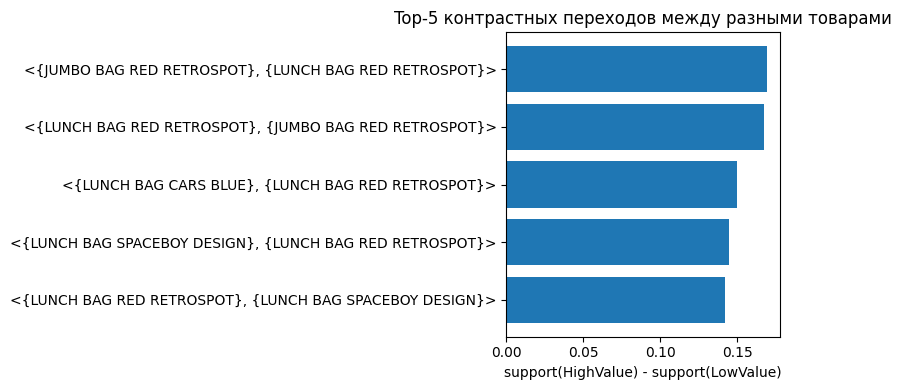

In [13]:
segments = pd.read_csv(DATA_DIR / 'client_value_segments.csv')
high_ids = set(segments.loc[segments['segment'] == 'HighValue', 'client_id'].astype(str))
low_ids = set(segments.loc[segments['segment'] == 'LowValue', 'client_id'].astype(str))

high_seq = [s for s in sequences if s['client_id'] in high_ids]
low_seq = [s for s in sequences if s['client_id'] in low_ids]

# Для двух групп ищу шаблоны отдельно, чтобы сравнить поддержки
high_res = apriori_all(high_seq, min_sup=0.10, max_len=2)
low_res = apriori_all(low_seq, min_sup=0.10, max_len=2)

contrast_rows = []
for p, high_cnt in high_res['patterns'].items():
    if len(p) < 2 or not is_distinct_transition(p):
        continue
    low_cnt = low_res['patterns'].get(p, support_count(p, low_seq))
    high_support = high_cnt / len(high_seq)
    low_support = low_cnt / len(low_seq)
    contrast_rows.append({
        'pattern': pattern_text(p),
        'pattern_object': p,
        'high_support': high_support,
        'low_support': low_support,
        'contrast': high_support - low_support
    })

contrast_df = pd.DataFrame(contrast_rows).sort_values('contrast', ascending=False).head(5)
display(contrast_df.drop(columns=['pattern_object']))

plt.figure(figsize=(8, 4))
plt.barh(contrast_df['pattern'], contrast_df['contrast'])
plt.xlabel('support(HighValue) - support(LowValue)')
plt.title('Top-5 контрастных переходов между разными товарами')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / 'contrast_patterns.png', dpi=150)
plt.show()

**Вывод.** Самые контрастные переходы у HighValue связаны в основном с группой lunch bag и `JUMBO BAG RED RETROSPOT`. Например, переход `JUMBO BAG RED RETROSPOT -> LUNCH BAG RED RETROSPOT` имеет поддержку около 17.8% у HighValue и только около 0.9% у LowValue. Контраст получается примерно 0.169.

Это означает, что такие переходы намного характернее для клиентов с высокой суммарной выручкой. Вероятная интерпретация: HighValue-клиенты чаще покупают несколько похожих или дополняющих друг друга товаров, то есть собирают наборы, а не делают одиночные покупки.

Для бизнеса это можно использовать как ранний сигнал ценного клиента. Если покупатель начинает повторять такие переходы, ему можно предложить персональную подборку товаров из той же серии или промокод на комплект.

## Общий вывод

В работе реализован AprioriAll, проверена его работа на маленьком примере и выполнен анализ реального датасета Online Retail. На синтетических данных алгоритм дал ожидаемый ручной результат, значит базовая логика генерации кандидатов и подсчета поддержки работает корректно.

На реальных данных видно, что параметры сильно влияют на результат: при росте `min_sup` с 5% до 20% число шаблонов упало с 67 до 4, а добавление окна `max_gap = 7` дней уменьшило число шаблонов с 67 до 36. Это показывает, что последовательные закономерности нужно подбирать под бизнес-задачу: для общих привычек можно брать большое окно, а для быстрых рекомендаций лучше ограничивать разрыв во времени.

Сравнение с PrefixSpan показало, что библиотечный алгоритм значительно быстрее моей реализации AprioriAll. В задаче рекомендаций последовательный подход также оказался полезнее глобального топ-товара: accuracy@1 равна 40% против 15%. Контрастные последовательности дополнительно показали, какие переходы товаров чаще встречаются у HighValue-клиентов, поэтому такие шаблоны можно использовать для персональных предложений и раннего выделения ценных покупателей.